# Drug Substance Manufacturing Process Optimization (IP)

This notebook provides an interactive integer programming (IP) workflow for the drug substance flowsheet configuration problem.
It mirrors the structure of the QUBO notebook, but solves directly with Pyomo + Gurobi and supports iterative integer cuts to enumerate feasible configurations.

This case study describes a configuration selection optimization problem (discrete) for a flowsheet optimization of a drug substance manufacturing process.
The manufacturing process consists of 5 unit operations: reaction 1, reaction 2, vaporization, crystallization, and filtration, with alternative unit selections at key operations.

The objective of the IP model is to minimize capital cost subject to flow conservation, disjunction logic, and process-selection constraints.
The iterative solve mode adds integer cuts (no-good cuts) to find multiple distinct feasible solutions.

<figure>
    <img src="../images/ds_opt_flowsheet.jpg" alt="DS Optimization Flowsheet" style="width: 100%; max-width: 800px;"/>
    <figcaption>Figure 1: Superstructure flowsheet of drug substance manufacturing process.</figcaption>
</figure>

In [1]:
# Imports
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from flst_opti_IP import FlowsheetOptimizer, PyomoModel, get_default_paths
from ds_mfg_utils import import_data, read_sim_data, visualize_network, export_to_mps

# Data Collection

In [2]:
# Notebook-friendly path configuration
cwd = Path.cwd()

if (cwd / "flst_opti_IP.py").exists():
    script_dir = cwd
elif (cwd / "ds-mfg" / "discrete_ip" / "flst_opti_IP.py").exists():
    script_dir = cwd / "ds-mfg" / "discrete_ip"
else:
    raise FileNotFoundError("Could not locate flst_opti_IP.py from current working directory.")

default_flowsheet_data, default_simulation_data = get_default_paths()

flowsheet_data_path = Path(default_flowsheet_data)
simulation_data_path = Path(default_simulation_data)

# Solver controls
max_iterations = 36      # Set to 36 for full run
solver_name = "gurobi"
tee = False
save = False
json_filename = None    # Set explicit filename string for deterministic output

print(f"Script directory: {script_dir}")
print(f"Flowsheet data path: {flowsheet_data_path}")
print(f"Simulation data path: {simulation_data_path}")

Script directory: /home/yirangpark/repos/secquoia/pd_ising/ds-mfg/discrete_ip
Flowsheet data path: /home/yirangpark/repos/secquoia/pd_ising/ds-mfg/discrete_ip/data/ssopt_gen_1.csv
Simulation data path: /home/yirangpark/repos/secquoia/pd_ising/ds-mfg/simulation/data/obj_mass_prod_crys/run_objmassprodcrys_sum.csv


In [3]:
# Load flowsheet data summary
flow_network, flow_cost, disj_dict, flow_with_uo, uo_keys = import_data(str(flowsheet_data_path))

print(f"Number of flows: {len(flow_network)}")
print(f"Number of disjunction groups: {len(disj_dict)}")
print(f"Number of flows associated with unit operations: {len(flow_with_uo)}")
print("\nSample flow definitions:")
for k in list(flow_network.keys())[:5]:
    print(f"  {k}: {flow_network[k]}, cost={flow_cost[k]}")

Number of flows: 19
Number of disjunction groups: 5
Number of flows associated with unit operations: 14

Sample flow definitions:
  f00: ('n00', 'n01'), cost=0.0
  f01: ('n01', 'n02'), cost=0.0289
  f02: ('n01', 'n02'), cost=0.0399
  f03: ('n01', 'n02'), cost=0.1225
  f04: ('n02', 'n03'), cost=0.0


In [4]:
# Optional: load simulation summary data if available
summary_data = None
if simulation_data_path.exists():
    summary_data = read_sim_data(str(simulation_data_path))
    print(f"Loaded simulation summary rows: {len(summary_data)}")
else:
    print(f"Simulation data not found at {simulation_data_path}; continuing without simulation matching.")

Loaded simulation summary rows: 40


# Build and Solve IP Model

In [7]:
# Solve iteratively with integer cuts
sim_data_arg = str(simulation_data_path) if simulation_data_path.exists() else None
optimizer = FlowsheetOptimizer(str(flowsheet_data_path), sim_data_arg)

results_dict = optimizer.solve_iteratively(
    max_iterations=max_iterations,
    solver_name=solver_name,
    tee=tee,
    save=save,
    json_filename=json_filename,
)

print(f"\nOptimization completed in {optimizer.iterations} iterations")
print(f"Total solve time: {optimizer.solve_time_sum:.3f} seconds")

Iteration 1 - Configuration: ['batch', 'batch', 'batch', 'cont1']
Objective function value: 11.7095
Termination condition: optimal
Solve time: 0.0141 seconds
Total solve time so far: 0.0141 seconds
Integer cut 1 added
--------------------------------------------------------------------------------
Iteration 2 - Configuration: ['batch', 'batch', 'batch', 'cont2']
Objective function value: 11.8105
Termination condition: optimal
Solve time: 0.0006 seconds
Total solve time so far: 0.0147 seconds
Integer cut 2 added
--------------------------------------------------------------------------------
Iteration 3 - Configuration: ['batch', 'batch', 'batch', 'cont3']
Objective function value: 12.2415
Termination condition: optimal
Solve time: 0.0006 seconds
Total solve time so far: 0.0153 seconds
Integer cut 3 added
--------------------------------------------------------------------------------
Iteration 4 - Configuration: ['PFR', 'PFR', 'batch', 'cont1']
Objective function value: 14.4569
Termina

# Data Analysis

These results may be collected from Data Collection section or imported from saved files.

In [8]:
# Convert in-memory iterative results to a dataframe for analysis
if not results_dict:
    raise ValueError("No results available. Run the solve cell first.")

records = []
for iteration, data in results_dict.items():
    records.append({
        "iteration": int(iteration),
        "operating_modes": ", ".join(data.get("operating_modes", [])),
        "ip_obj_value": data.get("ip_obj_value"),
        "termination_condition": data.get("termination_condition"),
        "solve_time": data.get("solve_time"),
        "sm_obj_value": data.get("sm_obj_value"),
        "sm_eval_time": data.get("sm_eval_time"),
        "sm_capex": data.get("sm_capex"),
    })

results_df = pd.DataFrame(records).sort_values("iteration").reset_index(drop=True)
results_df

,iteration,operating_modes,ip_obj_value,termination_condition,solve_time,sm_obj_value,sm_eval_time,sm_capex
0,1,"batch, batch, batch, cont1",11.7095,optimal,0.014119,-1.371860e+02,398,2.041896
1,2,"batch, batch, batch, cont2",11.8105,optimal,0.000570,-1.488184e+02,996,2.081873
2,3,"batch, batch, batch, cont3",12.2415,optimal,0.000604,-1.504775e+02,2119,2.101980
3,4,"PFR, PFR, batch, cont1",14.4569,optimal,0.001162,-3.351529e+02,793,17.257557
4,5,"CSTR, PFR, batch, cont1",14.4679,optimal,0.009252,-2.127217e+02,804,17.311533
5,6,"batch, PFR, batch, cont1",14.5505,optimal,0.007203,-2.220064e+02,842,10.311169
6,7,"PFR, PFR, batch, cont2",14.5579,optimal,0.002139,-3.313826e+02,1424,17.312532
7,8,"CSTR, PFR, batch, cont2",14.5689,optimal,0.001891,-2.210641e+02,1286,17.311189
8,9,"batch, PFR, batch, cont2",14.6515,optimal,0.002095,NaN,1063,NaN
9,10,"PFR, PFR, batch, cont3",14.9889,optimal,0.003573,-1.740628e+02,5865,6.863723


Dropped 1 rows with NaN/non-finite sim objective or CAPEX.
Dropped 1 rows with |sm_obj_value| >= 1e9.


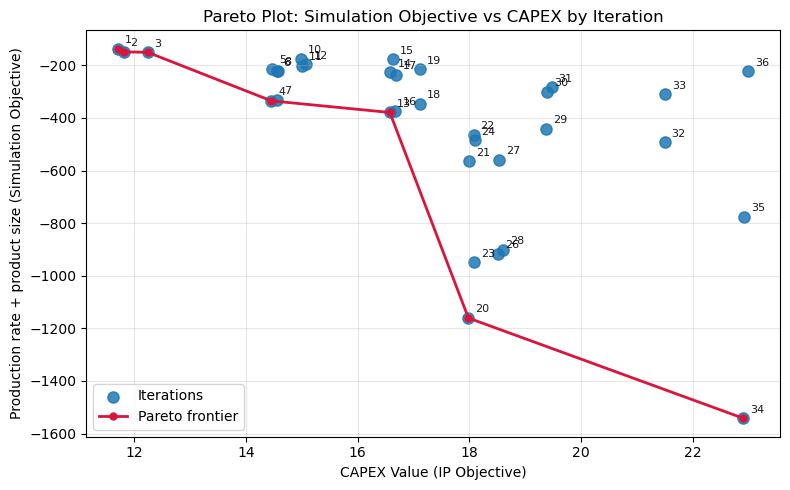

In [10]:
from ds_mfg_plotting import plot_pareto_front
plot_pareto_front(results_df)

# Import Data for Analysis
Use this section to import previous IP runs. If data was collected in Data Collection, this step is not necessary.

In [ ]:
# Load a previous JSON result from result_gurobi
import_dir = script_dir / "result_gurobi"

# Update this to a specific file if needed
candidate_files = sorted(import_dir.glob("gurobi_nogoodcuts_results_*.json"))
selected_json = candidate_files[-1] if candidate_files else None

if selected_json is None:
    print("No saved no-good-cut JSON file found in result_gurobi.")
else:
    print(f"Importing: {selected_json.name}")
    with open(selected_json, "r") as f:
        imported_results = json.load(f)

    imported_records = []
    for iteration, data in imported_results.items():
        imported_records.append({
            "iteration": int(iteration),
            "operating_modes": ", ".join(data.get("operating_modes", [])),
            "ip_obj_value": data.get("ip_obj_value"),
            "termination_condition": data.get("termination_condition"),
            "solve_time": data.get("solve_time"),
        })

    imported_df = pd.DataFrame(imported_records).sort_values("iteration").reset_index(drop=True)
    display(imported_df.head())